In [1]:
import numpy as np
import matplotlib.pyplot as plt
from diffsky.data_loaders.hacc_utils import load_lc_mock as llcm
import os
# from ellipse_proj_kernels import compute_ellipse2d, Ellipse2DParams
# from ellipse_proj_kernels_IA_alt import rotation_matrix_align_x_to_vector, compute_ellipse2d_with_IA, rotation_matrix_align_A_to_B, rotate_forward, rotate_inverse, compound_rotation_matrix
from halotools.utils.mcrotations import random_perpendicular_directions
from halotools.utils import elementwise_dot, angles_between_list_of_vectors, normalized_vectors
from ellipse_proj_dumb import compute_ellipse2d_dumb
import opencosmo as oc
import time
import h5py

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [2]:
def zero_mask(vec):
    nulls = np.ones(len(vec)).astype(bool)
    if len(vec.shape) > 1:
        for i in range(vec.shape[1]):
            nulls &= vec[:,i] == 0
    else:
        nulls &= vec == 0
    return nulls

def nan_mask(vec):
    nans = np.zeros(len(vec)).astype(bool)
    if len(vec.shape) > 1:
        for i in range(vec.shape[1]):
            nans |= np.isnan(vec[:,i])
    else:
        nans |= np.isnan(vec)
    return nans

def sum_zero_vec(vec):
    nulls = zero_mask(vec)
    return sum(nulls)

def bad_mask(vec):
    return zero_mask(vec) | nan_mask(vec)

def check_bad_axes(pos, a, b, c, major, inter, minor):
    print("Nan Counts:")
    print(f"pos: {sum(np.isnan(pos))}")
    print(f"a: {sum(np.isnan(a))}")
    print(f"b: {sum(np.isnan(b))}")
    print(f"c: {sum(np.isnan(c))}")
    print(f"major: {sum(np.isnan(major))}")
    print(f"inter: {sum(np.isnan(inter))}")
    print(f"minor: {sum(np.isnan(minor))}")

    print("\nZero Counts:")
    print(f"pos: {sum_zero_vec(pos)}")
    print(f"a: {sum_zero_vec(a)}")
    print(f"b: {sum_zero_vec(b)}")
    print(f"c: {sum_zero_vec(c)}")
    print(f"major: {sum_zero_vec(major)}")
    print(f"inter: {sum_zero_vec(inter)}")
    print(f"minor: {sum_zero_vec(minor)}")

def replace_bad_axes(major, inter, minor, mask):
    pass

In [3]:
# File and directory information
main_dir = "/global/cfs/cdirs/hacc/OpenCosmo/LastJourney/synthetic_galaxies/"
sim = "smdpl_dr1_latest"
sim_dir = os.path.join(main_dir, sim)
mock_file = "lc_cores-208.diffsky_gals.hdf5"

In [4]:
# # Load halos
# patch = llcm.load_diffsky_lc_patch(sim_dir, mock_file)

In [5]:
dataset = oc.open(os.path.join(sim_dir, mock_file))

In [6]:
N = len(dataset)
dataset = dataset.take(N, at="start")

In [7]:
print(f"{N} Galaxies")

423104 Galaxies


In [8]:
cols = ["top_host_infall_fof_halo_eigS1X", "top_host_infall_fof_halo_eigS1Y", "top_host_infall_fof_halo_eigS1Z",
       "top_host_infall_fof_halo_eigS2X", "top_host_infall_fof_halo_eigS2Y", "top_host_infall_fof_halo_eigS2Z",
       "top_host_infall_fof_halo_eigS3X", "top_host_infall_fof_halo_eigS3Y", "top_host_infall_fof_halo_eigS3Z",
       "x","y","z"]

In [9]:
data = dataset.select(cols).get_data("numpy")

In [10]:
major_axis = np.array([data["top_host_infall_fof_halo_eigS1X"], data["top_host_infall_fof_halo_eigS1Y"], data["top_host_infall_fof_halo_eigS1Z"]]).T
inter_axis = np.array([data["top_host_infall_fof_halo_eigS2X"], data["top_host_infall_fof_halo_eigS2Y"], data["top_host_infall_fof_halo_eigS2Z"]]).T
minor_axis = np.array([data["top_host_infall_fof_halo_eigS3X"], data["top_host_infall_fof_halo_eigS3Y"], data["top_host_infall_fof_halo_eigS3Z"]]).T
pos = np.array([data["x"],data["y"],data["z"]]).T

In [11]:
# Replace bad axes with randoms
axis_mask = bad_mask(major_axis) | bad_mask(inter_axis) | bad_mask(minor_axis)
pos_mask = bad_mask(pos)
print(f"{sum(axis_mask)} bad axes, assigning random orientations")
print(f"{sum(pos_mask)} bad positions, assigning random positions")
print("FOR NOW, JUST IGNORE THESE BAD VECTORS. RANDOMIZE THEM LATER")

mask = pos_mask | axis_mask
# major_axis = major_axis[~mask]
# inter_axis = inter_axis[~mask]
# minor_axis = minor_axis[~mask]
# pos = pos[~mask]
N = sum(~mask)

6442 bad axes, assigning random orientations
0 bad positions, assigning random positions
FOR NOW, JUST IGNORE THESE BAD VECTORS. RANDOMIZE THEM LATER


In [12]:
a = np.linalg.norm(major_axis, axis=-1)
b = np.linalg.norm(inter_axis, axis=-1)
c = np.linalg.norm(minor_axis, axis=-1)

In [13]:
major_normed = normalized_vectors(major_axis)
inter_normed = normalized_vectors(inter_axis)
minor_normed = normalized_vectors(minor_axis)

In [14]:
check_bad_axes(pos, a, b, c, major_axis, inter_axis, minor_axis)

Nan Counts:
pos: [0 0 0]
a: 0
b: 0
c: 0
major: [0 0 0]
inter: [0 0 0]
minor: [0 0 0]

Zero Counts:
pos: 0
a: 6442
b: 6442
c: 6442
major: 6442
inter: 6442
minor: 6442


In [15]:
# Project halos
start_ind = 0
batch_size = 40000
batches = int(N/batch_size)+1

alpha = np.zeros(len(a))
beta = np.zeros(len(a))
e_alpha = np.zeros(shape=(len(a),2))
e_beta = np.zeros(shape=(len(a),2))

for i in range(batches):
    print(f"{start_ind}-{start_ind+batch_size} / {N}")
    start = time.time()
    sub_mask = ~mask[start_ind:start_ind+batch_size]
    ellipse2d = compute_ellipse2d_dumb(a[start_ind:start_ind+batch_size][sub_mask], b[start_ind:start_ind+batch_size][sub_mask], 
                                       c[start_ind:start_ind+batch_size][sub_mask],
                                       pos[start_ind:start_ind+batch_size][sub_mask], 
                                       major_normed[start_ind:start_ind+batch_size][sub_mask], inter_normed[start_ind:start_ind+batch_size][sub_mask], 
                                       minor_normed[start_ind:start_ind+batch_size][sub_mask])
    # e_alpha.append( ellipse2d["e_alpha"] )
    # e_beta.append( ellipse2d["e_beta"] )
    # beta.append( ellipse2d["beta"] )
    # alpha.append( ellipse2d["alpha"] )
    alpha[start_ind:start_ind+batch_size][sub_mask] = ellipse2d["alpha"]
    beta[start_ind:start_ind+batch_size][sub_mask] = ellipse2d["beta"]
    e_alpha[start_ind:start_ind+batch_size][sub_mask] = ellipse2d["e_alpha"]
    e_beta[start_ind:start_ind+batch_size][sub_mask] = ellipse2d["e_beta"]
    print("Time = ",time.time()-start)
    
    start_ind += batch_size

0-40000 / 416662
Time =  216.11178851127625
40000-80000 / 416662
Time =  199.67931270599365
80000-120000 / 416662
Time =  190.75949549674988
120000-160000 / 416662


KeyboardInterrupt: 

# Ellipse Tests

In [30]:
def degenerate_ellipse_params(pts):
    """
    For a collinear point cloud, return ellipse params as if it were a 
    maximally eccentric (degenerate) ellipse along the line direction.
    Returns: x0, y0, ap, bp, e, phi  (same format as cart_to_pol)
    """
    center = pts.mean(axis=0)
    x0, y0 = center

    centered = pts - center
    _, _, Vt = np.linalg.svd(centered, full_matrices=False)
    axis = Vt[0]  # unit vector along the line

    # Semi-major axis = half the length of the line
    ap = np.max(np.abs(centered @ axis))
    # Semi-minor axis: small but nonzero to avoid downstream division issues
    bp = ap * 1e-6  # or a fixed small value like 1e-3 depending on your scale

    e = np.sqrt(1 - (bp / ap)**2)  # will be very close to 1

    # phi: angle of the line direction from the x-axis, in [0, pi)
    phi = np.arctan2(axis[1], axis[0]) % np.pi

    return x0, y0, ap, bp, e, phi


def get_ellipse_coefficients_alt(pts, multi=True):
    if not multi:
        centered = pts - pts.mean(axis=0)
        if np.linalg.matrix_rank(centered, tol=1e-10) < 2:
            return degenerate_ellipse_params(pts)
        coeffs = fit_ellipse(pts[:,0], pts[:,1])
        return cart_to_pol(coeffs)
    else:
        results = []
        for i in range(len(pts)):
            centered = pts[i] - pts[i].mean(axis=0)
            if np.linalg.matrix_rank(centered, tol=1e-10) < 2:
                results.append(degenerate_ellipse_params(pts[i]))
            else:
                coeffs = fit_ellipse(pts[i][:,0], pts[i][:,1])
                results.append(cart_to_pol(coeffs))
        return np.array(results)

def cart_to_pol_alt(coeffs):
    """

    Convert the cartesian conic coefficients, (a, b, c, d, e, f), to the
    ellipse parameters, where F(x, y) = ax^2 + bxy + cy^2 + dx + ey + f = 0.
    The returned parameters are x0, y0, ap, bp, e, phi, where (x0, y0) is the
    ellipse centre; (ap, bp) are the semi-major and semi-minor axes,
    respectively; e is the eccentricity; and phi is the rotation of the semi-
    major axis from the x-axis.

    """

    # We use the formulas from https://mathworld.wolfram.com/Ellipse.html
    # which assumes a cartesian form ax^2 + 2bxy + cy^2 + 2dx + 2fy + g = 0.
    # Therefore, rename and scale b, d and f appropriately.
    coeffs = np.real(coeffs)
    a = coeffs[0]
    b = coeffs[1] / 2
    c = coeffs[2]
    d = coeffs[3] / 2
    f = coeffs[4] / 2
    g = coeffs[5]

    den = b**2 - a*c
    if den > 0:
        raise ValueError('coeffs do not represent an ellipse: b^2 - 4ac must'
                         ' be negative!')

    # The location of the ellipse centre.
    x0, y0 = (c*d - b*f) / den, (a*f - b*d) / den

    num = 2 * (a*f**2 + c*d**2 + g*b**2 - 2*b*d*f - a*c*g)
    fac = np.sqrt((a - c)**2 + 4*b**2)
    # The semi-major and semi-minor axis lengths (these are not sorted).
    ap = np.sqrt(num / den / (fac - a - c))
    bp = np.sqrt(num / den / (-fac - a - c))

    # Sort the semi-major and semi-minor axis lengths but keep track of
    # the original relative magnitudes of width and height.
    width_gt_height = True
    if ap < bp:
        width_gt_height = False
        ap, bp = bp, ap

    # The eccentricity.
    r = (bp/ap)**2
    if r > 1:
        r = 1/r
    e = np.sqrt(1 - r)

    # The angle of anticlockwise rotation of the major-axis from x-axis.
    if b == 0:
        phi = 0 if a < c else np.pi/2
    else:
        phi = np.arctan((2.*b) / (a - c)) / 2
        if a > c:
            phi += np.pi/2
    if not width_gt_height:
        # Ensure that phi is the angle to rotate to the semi-major axis.
        phi += np.pi/2
    phi = phi % np.pi

    return x0, y0, ap, bp, e, phi

In [20]:
from ellipse_projections import ellipsoid_vectorized, project_points, get_hull_points, get_ellipse_coefficients, fit_ellipse, cart_to_pol
import scipy
from shapely.geometry import Polygon

In [21]:
start_ind = 80000
batch_size = 40000
batches = int(N/batch_size)+1
sub_mask = ~mask[start_ind:start_ind+batch_size]

In [23]:
# Extracted bit of ellipse projection
temp_a = a[start_ind:start_ind+batch_size][sub_mask]
temp_b = b[start_ind:start_ind+batch_size][sub_mask]
temp_c = c[start_ind:start_ind+batch_size][sub_mask]
temp_pos = pos[start_ind:start_ind+batch_size][sub_mask]
temp_major_normed = major_normed[start_ind:start_ind+batch_size][sub_mask]
temp_inter_normed = inter_normed[start_ind:start_ind+batch_size][sub_mask]
temp_minor_normed = minor_normed[start_ind:start_ind+batch_size][sub_mask]

Ntheta = 100
Nphi = 100
theta = np.linspace(0, np.pi, Ntheta)
phi = np.linspace(0, 2*np.pi, Nphi)

temp_major_axes = temp_major_normed*temp_a[:, np.newaxis]
temp_inter_axes = temp_inter_normed*temp_b[:, np.newaxis]
temp_minor_axes = temp_minor_normed*temp_c[:, np.newaxis]

temp_ellipsoids = ellipsoid_vectorized(temp_pos, temp_major_axes, temp_inter_axes, temp_minor_axes, theta, phi)
temp_ellipses = project_points(temp_pos, temp_ellipsoids)

temp_hulls = get_hull_points(temp_ellipses)

In [33]:
# At some point, cart_to_pol will crash and I should see when and why
results = []
for i in range(len(temp_hulls)):
    centered = temp_hulls[i] - temp_hulls[i].mean(axis=0)
    if np.linalg.matrix_rank(centered, tol=1e-10) < 2:
        results.append(degenerate_ellipse_params(pts[i]))
    else:
        coeffs = fit_ellipse(temp_hulls[i][:,0], temp_hulls[i][:,1])
        results.append(cart_to_pol_alt(coeffs))

In [32]:
results == results_alt

True

In [29]:
coeffs

array([-2.73253070e-01-2.29494592e-09j, -2.73253070e-01+2.29494592e-09j,
       -7.82248020e-01+0.00000000e+00j, -7.82248020e-01-0.00000000e+00j,
       -5.59839973e-01-3.28380383e-08j, -5.59839973e-01+3.28380383e-08j,
       -6.60381593e-05-8.12272239e-09j, -6.60381593e-05+8.12272239e-09j,
       -9.35344028e-05+8.09483504e-08j, -9.35344028e-05-8.09483504e-08j,
        4.07676390e-06+8.65296783e-04j,  4.07676390e-06-8.65296783e-04j])

In [62]:
# Go bit by bit to see which one crashes the cart_to_pol


In [63]:
(coeffs_alt == coeffs_standard).all()

np.True_

In [47]:
i

3397

In [35]:
len(temp_ellipses[i])

10000

In [43]:
hulls[i]

array([[ 305.57193143, -213.48337001],
       [ 198.20948625, -138.47616774],
       [-305.69369942,  213.56842389]])

In [46]:
# centered = temp_ellipses[i] - temp_ellipses[i].mean(axis=0)
# np.linalg.matrix_rank(centered, tol=1e-10)
centered = hulls[i] - hulls[i].mean(axis=0)
np.linalg.matrix_rank(centered, tol=1e-10)

np.int64(1)

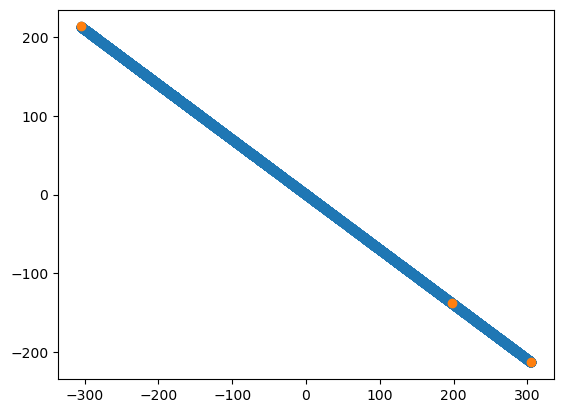

In [45]:
plt.scatter(temp_ellipses[i,:,0], temp_ellipses[i,:,1])
plt.scatter(hulls[i][:,0], hulls[i][:,1])

# Hull Tests

In [15]:
from ellipse_projections import ellipsoid_vectorized, project_points, get_hull_points, get_ellipse_coefficients
import scipy
from shapely.geometry import Polygon

In [21]:
start_ind = 80000
batch_size = 40000
batches = int(N/batch_size)+1
sub_mask = ~mask[start_ind:start_ind+batch_size]

In [22]:
# Extracted bit of ellipse projection
temp_a = a[start_ind:start_ind+batch_size][sub_mask]
temp_b = b[start_ind:start_ind+batch_size][sub_mask]
temp_c = c[start_ind:start_ind+batch_size][sub_mask]
temp_pos = pos[start_ind:start_ind+batch_size][sub_mask]
temp_major_normed = major_normed[start_ind:start_ind+batch_size][sub_mask]
temp_inter_normed = inter_normed[start_ind:start_ind+batch_size][sub_mask]
temp_minor_normed = minor_normed[start_ind:start_ind+batch_size][sub_mask]

Ntheta = 100
Nphi = 100
theta = np.linspace(0, np.pi, Ntheta)
phi = np.linspace(0, 2*np.pi, Nphi)

temp_major_axes = temp_major_normed*temp_a[:, np.newaxis]
temp_inter_axes = temp_inter_normed*temp_b[:, np.newaxis]
temp_minor_axes = temp_minor_normed*temp_c[:, np.newaxis]

temp_ellipsoids = ellipsoid_vectorized(temp_pos, temp_major_axes, temp_inter_axes, temp_minor_axes, theta, phi)
temp_ellipses = project_points(temp_pos, temp_ellipsoids)

# Crashes on the next step, which would be the hull, so let's NOT run this next line, but see what all my inputs look like
# hulls = get_hull_points(ellipses)

In [23]:
hull_lens = [len(temp_ellipses[i]) for i in range(len(temp_ellipses))]

In [39]:
min(hull_lens)

10000

In [37]:
hulls = []
for i in range(len(temp_ellipses)):
    hull = scipy.spatial.ConvexHull(temp_ellipses[i])
    hulls.append( np.array(temp_ellipses[i][hull.vertices] ) )

QhullError: QH6154 Qhull precision error: Initial simplex is flat (facet 1 is coplanar with the interior point)

While executing:  | qhull i Qt
Options selected for Qhull 2020.2.r 2020/08/31:
  run-id 360407413  incidence  Qtriangulate  _pre-merge  _zero-centrum
  _max-width 7.1e+02  Error-roundoff 3e-13  _one-merge 1.5e-12
  _near-inside 7.6e-12  Visible-distance 6.1e-13  U-max-coplanar 6.1e-13
  Width-outside 1.2e-12  _wide-facet 3.6e-12  _maxoutside 1.8e-12

The input to qhull appears to be less than 2 dimensional, or a
computation has overflowed.

Qhull could not construct a clearly convex simplex from points:
- p4966(v3): 1.6e+02 -2.8e+02
- p2565(v2): 2e+02 -3.5e+02
- p2515(v1): -2e+02 3.5e+02

The center point is coplanar with a facet, or a vertex is coplanar
with a neighboring facet.  The maximum round off error for
computing distances is 3e-13.  The center point, facets and distances
to the center point are as follows:

center point    52.45   -93.81

facet p2565 p2515 distance

In [30]:
def safe_hull_vertices(pt_cloud, thickness=1e-3):
    """
    Returns hull vertex points (not a ConvexHull object).
    Falls back to a thin ellipse if the point cloud is collinear.
    """
    centered = pt_cloud - pt_cloud.mean(axis=0)
    if np.linalg.matrix_rank(centered, tol=1e-10) < 2:
        center = pt_cloud.mean(axis=0)
        _, _, Vt = np.linalg.svd(centered, full_matrices=False)
        axis = Vt[0]
        half_len = np.max(np.abs(centered @ axis))
        t = np.linspace(0, 2 * np.pi, 64, endpoint=False)
        perp = np.array([-axis[1], axis[0]])
        return center + np.outer(np.cos(t), axis) * half_len + np.outer(np.sin(t), perp) * thickness
    hull = scipy.spatial.ConvexHull(pt_cloud)
    return pt_cloud[hull.vertices]

def get_hull_points_alt(pts, multi=True):
    if not multi:
        hull = scipy.spatial.ConvexHull(pts)
        return pts[hull.vertices]
    return [safe_hull_vertices(pts[i]) for i in range(len(pts))]

def hull_iou(verts1, verts2):
    p1 = Polygon(verts1)
    p2 = Polygon(verts2)
    intersection = p1.intersection(p2).area
    union = p1.union(p2).area
    return intersection / union  # 1 = identical, 0 = no overlap

def hull_symmetric_difference(verts1, verts2):
    p1 = Polygon(verts1)
    p2 = Polygon(verts2)
    return p1.symmetric_difference(p2).area

# Normalize by average area to get a relative measure
def hull_difference_ratio(verts1, verts2):
    p1 = Polygon(verts1)
    p2 = Polygon(verts2)
    diff = p1.symmetric_difference(p2).area
    avg_area = (p1.area + p2.area) / 2
    return diff / avg_area  # 0 = identical, 2 = completely disjoint

def hull_hausdorff(verts1, verts2):
    p1 = Polygon(verts1)
    p2 = Polygon(verts2)
    return p1.hausdorff_distance(p2)  # 0 = identical boundaries

In [27]:
alt_hull = get_hull_points_alt(temp_ellipses)

In [42]:
results = [
    (hull_iou(v1, v2), hull_hausdorff(v1, v2), hull_difference_ratio(v1, v2))
    for v1, v2 in zip(hulls[:18000], alt_hull[:1800])
]
ious, hdists, sdiffs = zip(*results)
print(f"IoU:       mean={np.mean(ious):.4f}  min={np.min(ious):.4f}")
print(f"Hausdorff: mean={np.mean(hdists):.4f}  max={np.max(hdists):.4f}")
print(f"SymDiff:   mean={np.mean(sdiffs):.4f}  max={np.max(sdiffs):.4f}")

IoU:       mean=1.0000  min=1.0000
Hausdorff: mean=0.0000  max=0.0000
SymDiff:   mean=0.0000  max=0.0000


In [45]:
import time
start = time.time()
get_hull_points(temp_ellipses[:5000])
print(time.time()-start)
start = time.time()
get_hull_points_alt(temp_ellipses[:5000])
print(time.time()-start)

10.78567361831665
11.881942510604858


In [46]:
print(len(temp_ellipses))
print(i)
temp_ellipses[i]

39304
18546


array([[-114.11680972,  204.09796572],
       [-121.12479424,  216.63173985],
       [-127.64505175,  228.29321465],
       ...,
       [-127.64505175,  228.29321465],
       [-121.12479424,  216.63173985],
       [-114.11680972,  204.09796572]], shape=(10000, 2))

In [48]:
temp_ellipsoids[i].shape

(10000, 3)

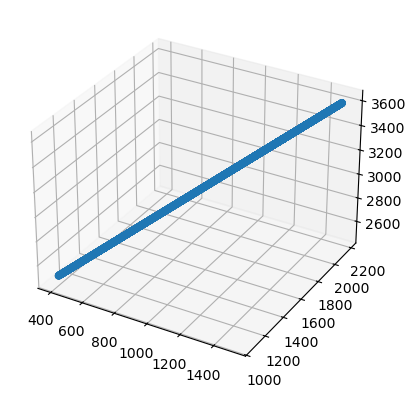

In [50]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(temp_ellipsoids[i,:,0], temp_ellipsoids[i,:,1], temp_ellipsoids[i,:,2])

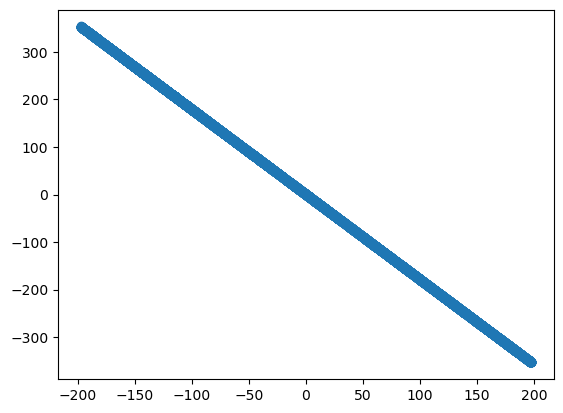

In [47]:
plt.scatter(temp_ellipses[i,:,0], temp_ellipses[i,:,1])

In [19]:
sum(~sub_mask)

np.int64(67)

# Saving

In [19]:
axis_mask_2d = bad_mask(e_alpha) | bad_mask(e_beta)
print(f"{sum(axis_mask)} bad axes")

19717 bad axes


In [20]:
import h5py

In [50]:
f_name = "projections.h5"
with h5py.File(f_name, 'a') as f:
    if not sim_dir in f:
        print("Here")
        f.create_group(sim_dir)
    group = f[sim_dir]

    if not mock_file.replace(".hdf5","") in group.keys():
        group.create_group(mock_file.replace(".hdf5",""))
    group = group[mock_file.replace(".hdf5","")]

    alpha_set = group.create_dataset("alpha", alpha.shape, dtype=alpha.dtype)
    beta_set = group.create_dataset("beta", beta.shape, dtype=beta.dtype)
    e_alpha_set = group.create_dataset("e_alpha", e_alpha.shape, dtype=e_alpha.dtype)
    e_beta_set = group.create_dataset("e_beta", e_beta.shape, dtype=e_beta.dtype)
    alpha_set[:] = alpha
    beta_set[:] = beta
    e_alpha_set[:] = e_alpha
    e_beta_set[:] = e_beta

ValueError: Unable to synchronously create dataset (name already exists)

In [56]:
f = h5py.File(f_name, 'r')

In [57]:
"lc_cores-121.diffsky_gals" in f[sim_dir]

True

In [52]:
f[sim_dir]["lc_cores-121.diffsky_gals"]["alpha"]

<HDF5 dataset "alpha": shape (296896,), type "<f8">

In [58]:
f.close()

In [54]:
N+19717

np.int64(296896)